# Encoder-based next-frame prediction

Amortized encoder `E(I)->r`, decoder `D`, ConvGRU on stored latents.

**Stage 1** — AE only (recon + modest cosine slowness). Adam, shuffled frame-pairs.
Gate: held-out recon MSE << next-frame target, and consec/unrelated `frac` well below 0.4.

**Stage 2** — freeze AE, precompute `r` sequences, train GRU on those latents. Adam, batched, 1-step teacher force + multi-step rollout.

No online settle, no per-frame manual SGD.


In [47]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "torch:", torch.__version__)


device: cpu torch: 2.13.0


In [48]:
if not os.path.exists("./data/MovingMNIST/mnist_test_seq.npy"):
    datasets.MovingMNIST._URL = "https://huggingface.co/datasets/goodgoodideas/STDN/resolve/main/mnist_test_seq.npy"
raw = datasets.MovingMNIST(root="./data", split=None, download=True)


def prep_seq(seq):
    x = seq.float() / 255.0
    if x.ndim == 3:
        x = x.unsqueeze(1)
    return torch.stack([fr - fr.mean() for fr in x], dim=0)


N_TRAIN, N_VAL = 64, 8
train_seqs = [prep_seq(raw[i]) for i in range(N_TRAIN)]
val_seqs = [prep_seq(raw[N_TRAIN + i]) for i in range(N_VAL)]
T = train_seqs[0].shape[0]
print(f"{N_TRAIN} train / {N_VAL} val sequences, T={T}, {tuple(train_seqs[0].shape)}")

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")



64 train / 8 val sequences, T=20, (20, 1, 64, 64)


define encoder and decoder

In [49]:
encoder = nn.Conv2d(1, 32, 4, stride=2, padding=1).to(device)
decoder = nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1).to(device)

define hyperparameters etc

In [50]:
from typing import Any


num_epochs = 100
learning_rate = 1e-3
batch_size = 32

train_frames = torch.cat(train_seqs, dim=0)  # (N*T, 1, 64, 64)
val_frames = torch.cat(val_seqs, dim=0)

train_loader = DataLoader(TensorDataset(train_frames), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(val_frames), batch_size=batch_size, shuffle=False)

optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()), lr=learning_rate
)

In [51]:
def train_loop(num_epochs, encoder, decoder, optimizer, train_loader):
    encoder.train()
    decoder.train()
    for epoch in range(num_epochs):
        total, n = 0.0, 0
        for (I,) in train_loader:
            I = I.to(device)
            I_hat = decoder(F.relu(encoder(I)))
            loss = F.mse_loss(I_hat, I)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total += loss.item() * I.shape[0]
            n += I.shape[0]
        print(f"Epoch {epoch + 1} recon MSE: {total / n:.6f}")
    return encoder, decoder

In [52]:
def plot_recon(frames, recons, n_show=8):
    frames = frames.detach().cpu()
    recons = recons.detach().cpu()
    n_show = min(n_show, frames.shape[0])
    fig, axes = plt.subplots(2, n_show, figsize=(1.5 * n_show, 3))
    if n_show == 1:
        axes = np.array(axes).reshape(2, 1)
    for i in range(n_show):
        axes[0, i].imshow(frames[i, 0], cmap="gray", vmin=-0.5, vmax=0.5)
        axes[0, i].set_title(f"True {i + 1}")
        axes[0, i].axis("off")
        axes[1, i].imshow(recons[i, 0], cmap="gray", vmin=-0.5, vmax=0.5)
        axes[1, i].set_title(f"Recon {i + 1}")
        axes[1, i].axis("off")
    plt.tight_layout()
    plt.show()


In [53]:
@torch.no_grad()
def val_loop(encoder, decoder, val_loader):
    encoder.eval()
    decoder.eval()
    total, n = 0.0, 0
    last_I, last_hat = None, None
    for (I,) in val_loader:
        I = I.to(device)
        I_hat = decoder(F.relu(encoder(I)))
        total += F.mse_loss(I_hat, I).item() * I.shape[0]
        n += I.shape[0]
        last_I, last_hat = I, I_hat
    mse = total / max(n, 1)
    print(f"Val recon MSE: {mse:.6f}")
    plot_recon(last_I, last_hat)
    return mse 

Epoch 1 recon MSE: 0.025320
Epoch 2 recon MSE: 0.006025
Epoch 3 recon MSE: 0.003281
Epoch 4 recon MSE: 0.002264
Epoch 5 recon MSE: 0.001593
Epoch 6 recon MSE: 0.001109
Epoch 7 recon MSE: 0.000836
Epoch 8 recon MSE: 0.000655
Epoch 9 recon MSE: 0.000522
Epoch 10 recon MSE: 0.000429
Epoch 11 recon MSE: 0.000360
Epoch 12 recon MSE: 0.000307
Epoch 13 recon MSE: 0.000265
Epoch 14 recon MSE: 0.000228
Epoch 15 recon MSE: 0.000198
Epoch 16 recon MSE: 0.000175
Epoch 17 recon MSE: 0.000155
Epoch 18 recon MSE: 0.000138
Epoch 19 recon MSE: 0.000124
Epoch 20 recon MSE: 0.000112
Epoch 21 recon MSE: 0.000102
Epoch 22 recon MSE: 0.000093
Epoch 23 recon MSE: 0.000085
Epoch 24 recon MSE: 0.000078
Epoch 25 recon MSE: 0.000072
Epoch 26 recon MSE: 0.000067
Epoch 27 recon MSE: 0.000062
Epoch 28 recon MSE: 0.000057
Epoch 29 recon MSE: 0.000053
Epoch 30 recon MSE: 0.000050
Epoch 31 recon MSE: 0.000047
Epoch 32 recon MSE: 0.000044
Epoch 33 recon MSE: 0.000041
Epoch 34 recon MSE: 0.000038
Epoch 35 recon MSE: 0.0

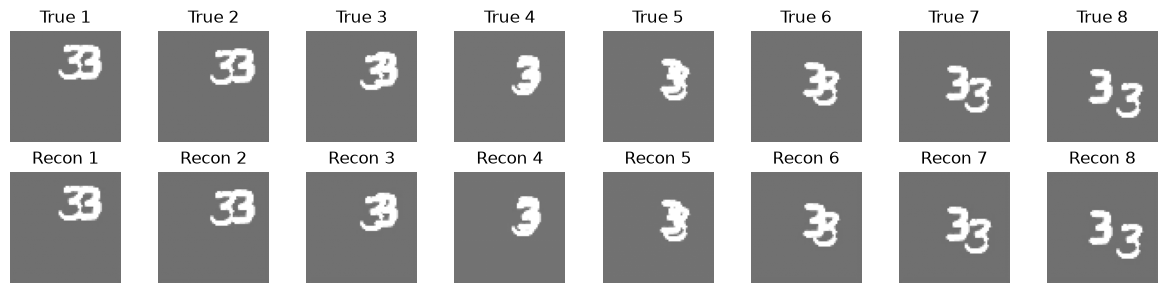

In [54]:
def main():
    train_loop(num_epochs, encoder, decoder, optimizer, train_loader)
    val_loop(encoder, decoder, val_loader)

if __name__ == "__main__":
    main()